In [347]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

In [348]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 20, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [349]:
#data = pd.read_csv("../Data/Day 2/5.36Hz2V.csv", sep = ",")
filename = "../Data/Day 3/53.1Hz2V.txt"
data = pd.read_table(filename)

In [350]:
# data init
downsampling = 1
i_min, i_max = (1,-1)
if "ms" in data["Time"][0]:
    time = np.array(data["Time"][i_min:i_max:downsampling].astype("float")) / 1000 # s
    print("ms")
else:
    time = np.array(data["Time"][i_min:i_max:downsampling].astype("float"))
channel_a = np.array(data["Channel B"][i_min:i_max:downsampling].astype("float"))
channel_b = np.array(data["Channel A"][i_min:i_max:downsampling].astype("float"))

match = re.search(r"([\d\.]+)Hz([\d\.]+)V", filename)
if match:
    f = float(match.group(1))
    V_max = float(match.group(2))  
print(f,V_max) 
T = 1/f # s
lamb = 650e-9 # m

ms
53.1 2.0


In [351]:
def pointFinder(y, t, ofs=0):
    # Centrer signalet omkring 0 for nemmere beregning
    y_centered = y - ofs
    
    # Find alle steder hvor signalet skifter fortegn
    sign_changes = np.where(np.diff(np.sign(y_centered)) != 0)[0]
    
    intersects = []
    t1 = []
    
    if len(sign_changes) > 0:
        intersects.append(sign_changes[0])
        t1.append(t[sign_changes[0]])
        
        for idx in sign_changes[1:]:
            if idx - intersects[-1] > 10: 
                intersects.append(idx)
                t1.append(t[idx])

    tops = []
    t2 = []
    for i in range(1, len(intersects)):
        start, end = intersects[i-1], intersects[i]
        interval_y = y[start:end]
        interval_t = t[start:end]
        
        if len(interval_y) == 0: continue

        # Afgør om intervallet er en top eller en dal
        if np.mean(interval_y) > ofs:
            idx = np.argmax(interval_y)
        else:
            idx = np.argmin(interval_y)
            
        tops.append(interval_y[idx])
        t2.append(interval_t[idx])

    intersects = np.array(intersects)
    t1 = np.array(t1)
    tops = np.array(tops)
    t2 = np.array(t2)
    
    dy = 0.1
    maske = (((tops) > (ofs + dy)) | ((tops) < (ofs - dy)))
    
    return intersects, t1, tops[maske], t2[maske]

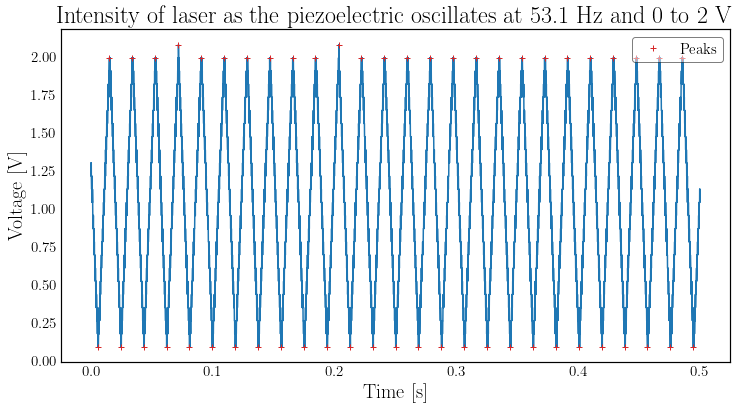

In [352]:
_, _, tops, times = pointFinder(channel_b, time, ofs=np.mean(channel_b))
fig, ax = plt.subplots()

ax.plot(time, channel_b, color="C0")
ax.plot(times, tops, "+", color = "C3", label = "Peaks")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title(f"Intensity of laser as the piezoelectric oscillates at {f} Hz and 0 to {Vmax} V")
ax.legend()

In [353]:
_, _, tops, times = pointFinder(channel_b, time, ofs=np.mean(channel_b))
indices = np.where(np.isin(time, times))[0]


new_time_parts = []
new_channel_b_parts = []
new_channel_a_parts = []
for j in range(int(tops[0] < 1),len(times)-1,2):
    start = indices[j]
    end = indices[j+1]

    interval = time[start:end]
    new_time_parts.append(interval - interval[0])
    new_channel_b_parts.append(channel_b[start:end])
    new_channel_a_parts.append(channel_a[start:end])

new_time_up = np.concatenate(new_time_parts)
new_channel_b_up = np.concatenate(new_channel_b_parts)
new_channel_a_up = np.concatenate(new_channel_a_parts)

new_time_parts = []
new_channel_b_parts = []
new_channel_a_parts = []
for j in range(int(tops[0] > 1),len(times)-1,2):
    start = indices[j]
    end = indices[j+1]

    interval = time[start:end]
    new_time_parts.append(interval - interval[0])
    new_channel_b_parts.append(channel_b[start:end])
    new_channel_a_parts.append(channel_a[start:end])

new_time_down = np.concatenate(new_time_parts)
new_channel_b_down = np.concatenate(new_channel_b_parts)
new_channel_a_down = np.concatenate(new_channel_a_parts)

In [354]:
a0 = (channel_a.max() - channel_a.min()) / 2
b0 = 1e-7
c0 = 0
d0 = (channel_a.max() + channel_a.min()) / 2

p0 = [a0, b0, c0, d0]

V_up = lambda t: (2 * Vmax / T * t)
fit_func_up = lambda t, a, b, c, d: a*np.cos(2*np.pi / lamb * 2 * b * V_up(t) + c) + d
fit_up = curve_fit(fit_func_up, new_time_up, new_channel_a_up, p0, ftol=1e-12, xtol=1e-12, gtol=1e-12)

V_down = lambda t: (-2 * Vmax / T * t + Vmax)
fit_func_down = lambda t, a, b, c, d: a*np.cos(2*np.pi / lamb * 2 * b * V_down(t) + c) + d
fit_down = curve_fit(fit_func_down, new_time_down, new_channel_a_down, p0, ftol=1e-12, xtol=1e-12, gtol=1e-12)

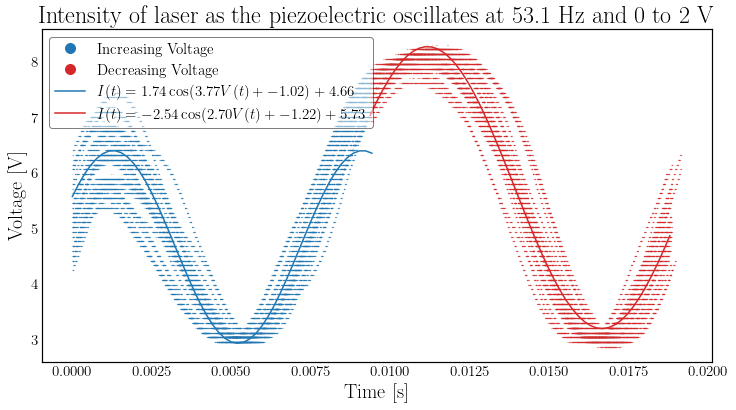

In [355]:
fig, ax = plt.subplots()

ax.plot(new_time_up, new_channel_a_up, "o", markersize = 0.1, color="C0", label ="Increasing Voltage")
ax.plot(new_time_down + new_time_up[-1], new_channel_a_down, "o", markersize = 0.1, color="C3", label = "Decreasing Voltage")

t = np.linspace(0, T/2)
a,b,c,d = fit_up[0]
ax.plot(t, fit_func_up(t,*fit_up[0]), color = "C0", label = f"$I(t) = {a:.2f}\\cos({4*np.pi*b/lamb:.2f} V(t) + {c:.2f}) + {d:.2f}$")
a,b,c,d = fit_down[0]
ax.plot(t + new_time_up[-1], fit_func_down(t,*fit_down[0]), color = "C3", label = f"$I(t) = {a:.2f}\\cos({4*np.pi*b/lamb:.2f} V(t) + {c:.2f}) + {d:.2f}$")

#ax.plot(times, tops, "+", color = "C3", label = "Peaks")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title(f"Intensity of laser as the piezoelectric oscillates at {f} Hz and 0 to {Vmax} V")
ax.legend(markerscale = 100)


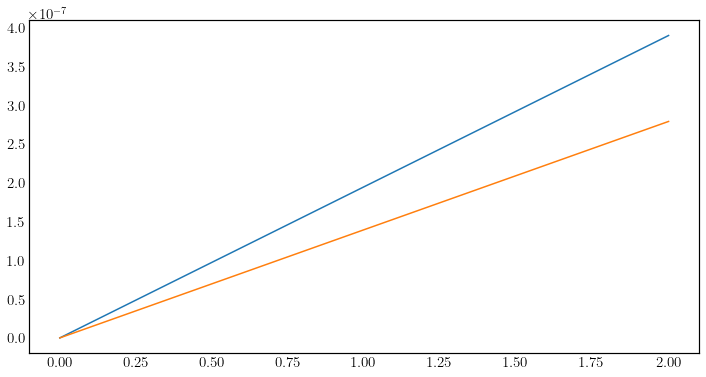

In [356]:
fig, ax = plt.subplots()
Vs = np.linspace(0,2,100)
ax.plot(Vs, fit_up[0][1] * Vs)
ax.plot(Vs, fit_down[0][1] * Vs)

1.8263718495272212


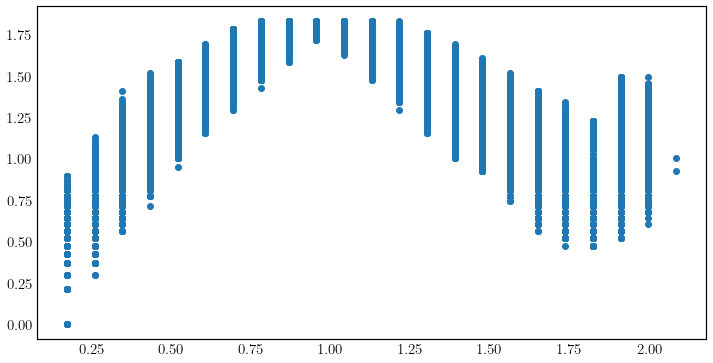

In [369]:
a = fit_up[0][0]
delta =  np.arccos(2 * new_channel_a_up / new_channel_a_up.max() - 1)
print(delta.max())

s = lamb / (2*np.pi)
fig, ax = plt.subplots()
ax.plot(new_channel_b_up, delta, "o")